# Instalar librerias necesarias para ejecutar el RAG y agentes de OpenAI

In [32]:
#%pip install -q -U google-genai langchain langchain-core langchain-community langchain-google-genai langchain-text-splitters langgraph python-dotenv pypdf

Note: you may need to restart the kernel to use updated packages.


In [33]:
import getpass
import os
from pathlib import Path

from dotenv import load_dotenv

load_dotenv()

if not os.getenv("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Google API key: ")

GENERATION_MODEL = "gemini-2.5-flash-lite"
EMBEDDING_MODEL = "models/gemini-embedding-001"

PDF_PATH = Path("../data/TENERIFE.pdf")
print("Modelo generativo:", GENERATION_MODEL)
print("Modelo de embeddings:", EMBEDDING_MODEL)
print("PDF:", PDF_PATH.resolve())

Modelo generativo: gemini-2.5-flash-lite
Modelo de embeddings: models/gemini-embedding-001
PDF: C:\Users\Usuario\OneDrive\Pontia\Modulo 6 - LLMs\Entrega Final\data\TENERIFE.pdf


In [35]:
from langchain.chat_models import init_chat_model
from langchain_google_genai import GoogleGenerativeAIEmbeddings

llm = init_chat_model(GENERATION_MODEL, model_provider="google_genai")
embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL)

In [ ]:
from langchain_community.document_loaders import PyPDFLoader

if not PDF_PATH.exists():
    raise FileNotFoundError(f"No se encontró el PDF en {PDF_PATH.resolve()}")

loader = PyPDFLoader(str(PDF_PATH))
docs = loader.load()

print("Número de páginas cargadas:", len(docs))
print("Metadata de la primera página:", docs[0].metadata)
print("Primeros caracteres:\n")
print(docs[0].page_content[:700])

C:\Users\Usuario\AppData\Local\Temp\ipykernel_13160\2503968503.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Número de páginas cargadas: 25
Metadata de la primera página: {'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2025-07-13T20:00:01+00:00', 'title': 'Microsoft Word - TENERIFE.docx', 'moddate': '2025-07-13T20:00:01+00:00', 'source': '..\\data\\TENERIFE.pdf', 'total_pages': 25, 'page': 0, 'page_label': '1'}
Primeros caracteres:

TENERIFE – LUGARES DE INTERÉS 
SITIOS QUE VER 
 
ZONA NORTE 
 
• Santa Cruz de Tenerife: 
Santa Cruz de Tenerife es la capital de la isla. Quizás la ruta a seguir si vais a Santa 
Cruz sería: 
- Aparcar en el aparcamiento del Parque Marítimo (ubicación). 
- Caminar por la Avenida Marítima hasta Plaza de España (ubicación). 
- Por el camino de la Avenida Marítima, ver el auditorio de Tenerife (ubicación). 
- Una vez llegados a Plaza España, callejear un poco (subir la Calle Castillo 
dirección Plaza Weyler - ubicación –; ir hacia el Parque García Sanabria - 
ubicación -; y bajar de nuevo hacia Plaza de España pasando por la Plaza del 
Príncipe -

In [40]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    add_start_index=True,
)
# El método split_documents devuelve una lista de Documentos, cada uno con su propio metadata y contenido.
splits = text_splitter.split_documents(docs)

# Añadimos un identificador simple a cada chunk para poder citarlo luego.
for i, doc in enumerate(splits):
    doc.metadata["chunk_id"] = i
    doc.metadata["source_name"] = PDF_PATH.name

print("Número de chunks:", len(splits))
print("\nEjemplo de chunk:\n")
print(splits[0].page_content)
print("\nMetadata:", splits[0].metadata)

Número de chunks: 46

Ejemplo de chunk:

TENERIFE – LUGARES DE INTERÉS 
SITIOS QUE VER 
 
ZONA NORTE 
 
• Santa Cruz de Tenerife: 
Santa Cruz de Tenerife es la capital de la isla. Quizás la ruta a seguir si vais a Santa 
Cruz sería: 
- Aparcar en el aparcamiento del Parque Marítimo (ubicación). 
- Caminar por la Avenida Marítima hasta Plaza de España (ubicación). 
- Por el camino de la Avenida Marítima, ver el auditorio de Tenerife (ubicación). 
- Una vez llegados a Plaza España, callejear un poco (subir la Calle Castillo

Metadata: {'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2025-07-13T20:00:01+00:00', 'title': 'Microsoft Word - TENERIFE.docx', 'moddate': '2025-07-13T20:00:01+00:00', 'source': '..\\data\\TENERIFE.pdf', 'total_pages': 25, 'page': 0, 'page_label': '1', 'start_index': 0, 'chunk_id': 0, 'source_name': 'TENERIFE.pdf'}


In [84]:
from langchain_core.vectorstores import InMemoryVectorStore

# Metemos los embeddings en el vector store(local)
vector_store = InMemoryVectorStore(embeddings)
# El método add_documents devuelve una lista de IDs generados para cada documento añadido al vector store.
document_ids = vector_store.add_documents(splits)

print("Documentos indexados:", len(document_ids))
print("Primeros IDs:", document_ids[:3])
#print("IDs creados por nosotros:", doc.metadata["chunk_id"])


Documentos indexados: 46
Primeros IDs: ['eb8b034a-94ca-479c-89de-06370b3793c6', '060bc885-d183-4767-99e4-b1fb5bd741da', '828ec32b-bcd8-4475-8547-148974dcb63d']


In [ ]:
for doc in splits:
    print(f"Chunk {doc.metadata['chunk_id']} | Página {doc.metadata.get('page')} | Caracteres: {len(doc.page_content)}")

Chunk 0 | Página 0 | Caracteres: 881
Chunk 1 | Página 1 | Caracteres: 86
Chunk 2 | Página 2 | Caracteres: 520
Chunk 3 | Página 3 | Caracteres: 379
Chunk 4 | Página 4 | Caracteres: 855
Chunk 5 | Página 5 | Caracteres: 124
Chunk 6 | Página 7 | Caracteres: 455
Chunk 7 | Página 8 | Caracteres: 1166
Chunk 8 | Página 9 | Caracteres: 219
Chunk 9 | Página 10 | Caracteres: 1168
Chunk 10 | Página 10 | Caracteres: 307
Chunk 11 | Página 11 | Caracteres: 1182
Chunk 12 | Página 11 | Caracteres: 681
Chunk 13 | Página 12 | Caracteres: 162
Chunk 14 | Página 13 | Caracteres: 373
Chunk 15 | Página 14 | Caracteres: 913
Chunk 16 | Página 15 | Caracteres: 776
Chunk 17 | Página 16 | Caracteres: 540
Chunk 18 | Página 17 | Caracteres: 382
Chunk 19 | Página 18 | Caracteres: 123
Chunk 20 | Página 19 | Caracteres: 92
Chunk 21 | Página 20 | Caracteres: 1031
Chunk 22 | Página 21 | Caracteres: 590
Chunk 23 | Página 22 | Caracteres: 388
Chunk 24 | Página 23 | Caracteres: 1192
Chunk 25 | Página 23 | Caracteres: 1197
C

## Experimentos para elegir chunk_size y chunk_overlap

Usa esta mini evaluación para comparar configuraciones de splitting con preguntas de validación.

Qué se calcula en esta versión:
- precision@k: proporción media de chunks relevantes dentro de los top-k recuperados (mide ruido vs precisión de recuperación).
- recall_keywords_at_k: cobertura media de keywords esperadas que aparecen en el contexto recuperado (mide si recuperas contenido útil).
- recall_page_at_k: proporción de preguntas donde aparece la página esperada dentro del top-k (mide acierto documental directo).
- hit_recall_at_k: proporción de preguntas con al menos un chunk relevante en top-k (mide éxito mínimo de retrieval).
- groundedness_proxy (faithfulness proxy): fracción de términos de la respuesta soportados por el contexto recuperado (mide qué tan fundamentada está la respuesta).

Pasos:
1. Ajusta `EVAL_SET` con 10-20 preguntas reales y keywords esperadas.
2. Ejecuta la celda de evaluación.
3. Elige la configuración con mejor equilibrio entre `precision_at_k`, `recall_keywords_at_k` y `groundedness_proxy` (evitando crecer demasiado `num_chunks`).

In [53]:
import re

import pandas as pd
from langchain_core.vectorstores import InMemoryVectorStore

# Rejilla inicial de pruebas (puedes ampliarla).
GRID = [
    {"chunk_size": 500, "chunk_overlap": 50},
    {"chunk_size": 800, "chunk_overlap": 120},
    {"chunk_size": 1000, "chunk_overlap": 120},
    {"chunk_size": 1200, "chunk_overlap": 180},
]

TOP_K = 3

# Si es True, genera respuestas para medir groundedness/faithfulness proxy.
# Puede aumentar coste y latencia porque invoca el LLM.
COMPUTE_GROUNDEDNESS = True

# Ajusta estas preguntas con el contenido real de tu PDF.
# expected_page es opcional pero recomendable si quieres una validación más estricta.
EVAL_SET = [
    {
        "question": "¿Qué puedo ver en Puerto de la Cruz?",
        "expected_keywords": ["puerto de la cruz", "playa jardín", "loro parque"],
        "expected_page": 11,
    },
    {
        "question": "¿Qué actividades hay en el Teide?",
        "expected_keywords": ["teide", "parque nacional", "teleférico"],
        "expected_page": 15,
    },
    {
        "question": "¿Qué playas destacan en Tenerife?",
        "expected_keywords": ["teresitas", "playas", "arena"],
        "expected_page": 23,
    },
    {
        "question": "¿Qué ver en San Cristóbal de La Laguna?",
        "expected_keywords": ["san cristóbal de la laguna", "patrimonio", "centro histórico"],
        "expected_page": [4, 5],
    },
    {
        "question": "¿Qué sitios para comer me recomiendas?",
        "expected_keywords": ["restaurantes", "comida", "vainas"],
        "expected_page": [24],
    },

]

def build_splitter(config):
    return RecursiveCharacterTextSplitter(
        chunk_size=config["chunk_size"],
        chunk_overlap=config["chunk_overlap"],
        add_start_index=True,
    )

def prepare_splits(config, docs):
    splitter = build_splitter(config)
    config_splits = splitter.split_documents(docs)

    for i, doc in enumerate(config_splits):
        doc.metadata["chunk_id"] = i
        doc.metadata["source_name"] = PDF_PATH.name

    return config_splits

def normalize_text(value):
    return str(value).lower().strip() if value is not None else ""

def as_list(value):
    if value is None:
        return []
    if isinstance(value, list):
        return value
    return [value]

def is_doc_relevant(doc, expected_keywords, expected_pages):
    text = normalize_text(doc.page_content)
    page = doc.metadata.get("page")
    keyword_hit = any(keyword in text for keyword in expected_keywords) if expected_keywords else False
    page_hit = page in expected_pages if expected_pages else False
    return keyword_hit or page_hit

def answer_with_context(question, recovered_docs):
    context = "\n\n".join(
        f"[Fuente {i}: pag {d.metadata.get('page', '?')}, chunk {d.metadata.get('chunk_id', '?')}]\n{d.page_content}"
        for i, d in enumerate(recovered_docs, start=1)
    )
    messages = rag_prompt.invoke({"question": question, "context": context})
    answer = llm.invoke(messages)
    return answer.content, context

def token_set(text):
    # Tokenizacion simple para un proxy robusto y reproducible.
    return set(re.findall(r"\b\w{4,}\b", normalize_text(text)))

def groundedness_proxy(answer, context):
    answer_tokens = token_set(answer)
    if not answer_tokens:
        return 0.0
    context_tokens = token_set(context)
    supported = len(answer_tokens & context_tokens)
    return round(supported / len(answer_tokens), 3)

def evaluate_config(config, docs, embeddings, eval_set, top_k=3, compute_groundedness=False):
    config_splits = prepare_splits(config, docs)

    store = InMemoryVectorStore(embeddings)
    store.add_documents(config_splits)

    # Agregados retrieval
    sum_precision_at_k = 0.0
    sum_recall_keywords_at_k = 0.0
    sum_recall_page_at_k = 0.0
    hit_recall_at_k = 0

    # Agregados groundedness
    sum_groundedness_proxy = 0.0
    groundedness_count = 0

    rows = []

    for item in eval_set:
        question = item["question"]
        recovered = store.similarity_search(question, k=top_k)
        recovered_text = " ".join(doc.page_content.lower() for doc in recovered)
        recovered_pages = [doc.metadata.get("page") for doc in recovered]

        expected_keywords = [
            normalize_text(keyword)
            for keyword in item.get("expected_keywords", [])
            if keyword
        ]
        expected_pages = as_list(item.get("expected_page"))

        # precision@k: fraccion de docs recuperados que son relevantes.
        relevant_docs = [
            doc for doc in recovered if is_doc_relevant(doc, expected_keywords, expected_pages)
        ]
        precision_at_k = len(relevant_docs) / top_k if top_k else 0.0

        # recall@k por keywords esperadas en contexto recuperado.
        keyword_matches = sum(1 for keyword in expected_keywords if keyword in recovered_text)
        recall_keywords_at_k = (
            keyword_matches / len(expected_keywords) if expected_keywords else 0.0
        )

        # recall@k por pagina esperada (hit binario por pregunta).
        page_hit = any(page in recovered_pages for page in expected_pages) if expected_pages else False
        recall_page_at_k = 1.0 if page_hit else 0.0

        # hit-rate@k: al menos un doc relevante entre los top-k.
        hit_at_k = 1.0 if len(relevant_docs) > 0 else 0.0

        sum_precision_at_k += precision_at_k
        sum_recall_keywords_at_k += recall_keywords_at_k
        sum_recall_page_at_k += recall_page_at_k
        hit_recall_at_k += int(hit_at_k)

        row = {
            "question": question,
            "expected_page": item.get("expected_page"),
            "recovered_pages": recovered_pages,
            "num_relevant_docs": len(relevant_docs),
            "precision_at_k": round(precision_at_k, 3),
            "recall_keywords_at_k": round(recall_keywords_at_k, 3),
            "recall_page_at_k": round(recall_page_at_k, 3),
            "hit_at_k": round(hit_at_k, 3),
        }

        if compute_groundedness:
            answer, context = answer_with_context(question, recovered)
            g_proxy = groundedness_proxy(answer, context)
            row["groundedness_proxy"] = g_proxy
            row["answer"] = answer
            sum_groundedness_proxy += g_proxy
            groundedness_count += 1

        rows.append(row)

    total = len(eval_set) if eval_set else 1

    return {
        "chunk_size": config["chunk_size"],
        "chunk_overlap": config["chunk_overlap"],
        "overlap_ratio": round(config["chunk_overlap"] / config["chunk_size"], 3),
        "num_chunks": len(config_splits),
        "precision_at_k": round(sum_precision_at_k / total, 3),
        "recall_keywords_at_k": round(sum_recall_keywords_at_k / total, 3),
        "recall_page_at_k": round(sum_recall_page_at_k / total, 3),
        "hit_recall_at_k": round(hit_recall_at_k / total, 3),
        "groundedness_proxy": round(
            (sum_groundedness_proxy / groundedness_count) if groundedness_count else 0.0,
            3,
        ),
        "rows": rows,
    }

results = [
    evaluate_config(
        cfg,
        docs,
        embeddings,
        EVAL_SET,
        top_k=TOP_K,
        compute_groundedness=COMPUTE_GROUNDEDNESS,
    )
    for cfg in GRID
]

summary_rows = [
    {
        "chunk_size": result["chunk_size"],
        "chunk_overlap": result["chunk_overlap"],
        "ratio": result["overlap_ratio"],
        "num_chunks": result["num_chunks"],
        "precision_at_k": result["precision_at_k"],
        "recall_keywords_at_k": result["recall_keywords_at_k"],
        "recall_page_at_k": result["recall_page_at_k"],
        "hit_recall_at_k": result["hit_recall_at_k"],
        "groundedness_proxy": result["groundedness_proxy"],
    }
    for result in results
]

summary = pd.DataFrame(summary_rows)
summary = summary.sort_values(
    by=[
        "recall_keywords_at_k",
        "precision_at_k",
        "groundedness_proxy",
        "hit_recall_at_k",
        "num_chunks",
    ],
    ascending=[False, False, False, False, True],
).reset_index(drop=True)

print("Resumen de evaluación:")
print("-" * 140)
print(summary.to_string(index=False))

best = results[0] if results else None
if best:
    print("\nMejor configuración sugerida:")
    print(
        {
            "chunk_size": best["chunk_size"],
            "chunk_overlap": best["chunk_overlap"],
            "overlap_ratio": best["overlap_ratio"],
            "num_chunks": best["num_chunks"],
            "precision_at_k": best["precision_at_k"],
            "recall_keywords_at_k": best["recall_keywords_at_k"],
            "recall_page_at_k": best["recall_page_at_k"],
            "hit_recall_at_k": best["hit_recall_at_k"],
            "groundedness_proxy": best["groundedness_proxy"],
        }
    )

    print("\nDetalle por pregunta para la mejor configuración:")
    detail = pd.DataFrame(best["rows"])
    print(detail.to_string(index=False))

Resumen de evaluación:
--------------------------------------------------------------------------------------------------------------------------------------------
 chunk_size  chunk_overlap  ratio  num_chunks  precision_at_k  recall_keywords_at_k  recall_page_at_k  hit_recall_at_k  groundedness_proxy
       1200            180   0.15          28           0.933                 0.800               0.8              1.0               0.774
        800            120   0.15          35           0.867                 0.733               0.6              1.0               0.781
       1000            120   0.12          30           0.800                 0.667               0.8              1.0               0.719
        500             50   0.10          46           0.733                 0.667               0.6              1.0               0.739

Mejor configuración sugerida:
{'chunk_size': 500, 'chunk_overlap': 50, 'overlap_ratio': 0.1, 'num_chunks': 46, 'precision_at_k': 0.733, 'rec

El flujo es:

1. Convertimos cada chunk en un vector.
2. Guardamos esos vectores en una base vectorial.
3. Cuando llega una pregunta, también la convertimos en vector.
4. Buscamos los chunks con vectores más parecidos al vector de la pregunta.

Usaremos `InMemoryVectorStore`, que vive en memoria. En producción usaríamos algo persistente como Chroma, FAISS, Qdrant, Pinecone, PGVector, Elasticsearch, etc.

In [54]:
def mostrar_documentos_recuperados(documentos):
    for i, doc in enumerate(documentos, start=1):
        print(f"Resultado {i}")
        print("Fuente:", doc.metadata.get("source_name"))
        print("Página:", doc.metadata.get("page"))
        print("Chunk:", doc.metadata.get("chunk_id"))
        print(doc.page_content)
        print("-" * 80)

pregunta = "¿Que puedo ver en el Puerto de la cruz?"
retrieved_docs = vector_store.similarity_search(pregunta, k=3)

mostrar_documentos_recuperados(retrieved_docs)

Resultado 1
Fuente: TENERIFE.pdf
Página: 10
Chunk: 16
Charco (los helados del Freddino no están mal por si os apetece) y, de ahí, de vuelta 
al coche. 
En el Puerto de la Cruz También se encuentra el Loro Parque, que ha sido 
considerado varios años como el Mejor Zoológico del Mundo. Normalmente es un 
must que hay que ver en las turistadas de Tenerife (entradas aquí) y, cerca, tenéis el 
Brunelli's Steakhouse por si os queréis hinchar a carne.
--------------------------------------------------------------------------------
Resultado 2
Fuente: TENERIFE.pdf
Página: 10
Chunk: 14
tendréis poca playa (especialmente a la del Ancón) y tened mucho respeto al mar en 
estas playas, que la corriente es muy traicionera. 
 
• Puerto de La Cruz 
Es la zona turística del Norte de Tenerife. De hecho, hace años era el núcleo turístico 
de la isla hasta que empezó a ganar mucho peso el Sur de Tenerife. 
 
 
Para visitar el Puerto de la Cruz, os recomendaría aparcar en la explanada del muelle 
e ir cami

In [55]:
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Eres un guia turistico, tienes que aportar información útil y precisa sobre destinos turísticos. "
            "Responde en español usando únicamente el contexto proporcionado. "
            "Si el contexto no contiene la respuesta, di claramente: 'No tengo información suficiente en la base documental'. "
            "No inventes datos. Cita las fuentes usadas al final.",
        ),
        (
            "user",
            "Pregunta:\n{question}\n\nContexto recuperado:\n{context}\n\nRespuesta:",
        ),
    ]
)

In [56]:
def format_docs_with_sources(documentos):
    bloques = []
    for i, doc in enumerate(documentos, start=1):
        source = doc.metadata.get("source_name", "fuente desconocida")
        page = doc.metadata.get("page", "?")
        chunk_id = doc.metadata.get("chunk_id", "?")
        bloques.append(
            f"[Fuente {i}: {source}, página {page}, chunk {chunk_id}]\n{doc.page_content}"
        )
    return "\n\n".join(bloques)


def answer_with_rag(question: str, k: int = 3, show_context: bool = False):
    retrieved_docs = vector_store.similarity_search(question, k=k)
    context = format_docs_with_sources(retrieved_docs)

    if show_context:
        print("CONTEXTO RECUPERADO")
        print(context)
        print("=" * 80)

    messages = rag_prompt.invoke({"question": question, "context": context})
    answer = llm.invoke(messages)

    return {
        "question": question,
        "answer": answer.content,
        "context": retrieved_docs,
        "prompt": messages,
    }

In [57]:
result = answer_with_rag(
    "¿Que playas puedo visitar en Tenerife?",
    k=3,
    show_context=True,
)

print(result["answer"])

CONTEXTO RECUPERADO
[Fuente 1: TENERIFE.pdf, página 22, chunk 37]
• El Médano / La Tejita 
Playas tipiquísimas de Tenerife y otra de las estampas de la isla con Montaña Roja al 
fondo. Nota: La Tejita es playa nudista para que lo tengáis en cuenta.  
 
 
• Los Cristianos 
De la zona de Los Cristianos que me venga a la mente os recomendaría la Playa de 
Los Cristianos o la Playa de Las Vistas y creo que poco más (la imagen es la Playa de 
Las Vistas).

[Fuente 2: TENERIFE.pdf, página 10, chunk 14]
tendréis poca playa (especialmente a la del Ancón) y tened mucho respeto al mar en 
estas playas, que la corriente es muy traicionera. 
 
• Puerto de La Cruz 
Es la zona turística del Norte de Tenerife. De hecho, hace años era el núcleo turístico 
de la isla hasta que empezó a ganar mucho peso el Sur de Tenerife. 
 
 
Para visitar el Puerto de la Cruz, os recomendaría aparcar en la explanada del muelle 
e ir caminando desde el Muelle hasta la Playa Martiánez recorriendo la Calle de

[Fuente 3:

In [58]:
# Misma pregunta reformulada de otra manera
result = answer_with_rag(
    "¿Qué lugares para bañarse hay en Tenerife?",
    k=3,
)

print(result["answer"])

En Tenerife puedes bañarte en:

*   **El Médano / La Tejita:** La Tejita es una playa nudista.
*   **Los Cristianos:** Se recomienda la Playa de Los Cristianos o la Playa de Las Vistas.
*   **Puerto de La Cruz:** Se recomienda la Playa Martiánez.
*   **Playa de Troya:**

[Fuente 1: TENERIFE.pdf]
[Fuente 2: TENERIFE.pdf]
[Fuente 3: TENERIFE.pdf]


In [65]:
#Prueba de pregunta que no esta en el RAG

result = answer_with_rag(
    "¿Que playas puedo visitar en Madrid?",
    k=3,
    show_context=True,
)

print(result["answer"])


CONTEXTO RECUPERADO
[Fuente 1: TENERIFE.pdf, página 9, chunk 13]
o La Playa de Los Patos 
o Playa del Ancón 
 
Nota: Para llegar estas playas hay que caminar un rato y algunas son de difícil acceso 
(la de Los Patos). También hay que ir a estas playas cuando la marea esté baja, si no

[Fuente 2: TENERIFE.pdf, página 19, chunk 31]
o Playa del Camisón 
Esta es una playa pequeñita que a nosotros en concreto nos gusta mucho.

[Fuente 3: TENERIFE.pdf, página 10, chunk 15]
Santo Domingo, la calle de San Telmo y la avenida de Cristóbal Colón. En este 
recorrido podréis ver la Plaza de Europa (quizás buen sitio para alguna fotillo desde 
la parte de arriba de la plaza) o el Lago de Martiánez, que son un conjunto de 
piscinas naturales. 
Una vez llegados a la Playa Martiánez, volvería por el mismo camino hasta el 
principio de la calle de San Telmo y bajaría por la calle Quintana hasta la Plaza del
No tengo información suficiente en la base documental.
{'question': '¿Que playas puedo visitar en

In [69]:

from langchain_core.documents import Document
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict


class RAGState(TypedDict):
    question: str
    context: list[Document]
    answer: str
    sources: list[dict]


def retrieve(state: RAGState):
    retrieved_docs = vector_store.similarity_search(state["question"], k=3)
    return {"context": retrieved_docs}


def generate(state: RAGState):
    context = format_docs_with_sources(state["context"])
    messages = rag_prompt.invoke({"question": state["question"], "context": context})
    response = llm.invoke(messages)
    sources = [
        {
            "source": doc.metadata.get("source_name"),
            "page": doc.metadata.get("page"),
            "chunk_id": doc.metadata.get("chunk_id"),
        }
        for doc in state["context"]
    ]
    return {"answer": response.content, "sources": sources}


graph_builder = StateGraph(RAGState)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)
graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve", "generate")
rag_graph = graph_builder.compile()

In [70]:
result = rag_graph.invoke({"question": "¿Que playas hay en Tenerife?"})

print("Respuesta:\n", result["answer"])
print("\nFuentes:")
for source in result["sources"]:
    print(source)

Respuesta:
 En Tenerife, algunas de las playas que puedes encontrar son:

*   **El Médano / La Tejita**: La Tejita es una playa nudista. [Fuente 1]
*   **Los Cristianos**: Se recomiendan la Playa de Los Cristianos y la Playa de Las Vistas. [Fuente 1]
*   **Playa del Ancón**: Se menciona en relación con el Puerto de La Cruz, advirtiendo sobre la corriente. [Fuente 2]
*   **Playa Martiánez**: Ubicada en Puerto de la Cruz. [Fuente 2]
*   **Playa de Benijo**: Es una playa de arena negra y se destaca por sus espectaculares atardeceres. [Fuente 3]

Fuentes:
{'source': 'TENERIFE.pdf', 'page': 22, 'chunk_id': 37}
{'source': 'TENERIFE.pdf', 'page': 10, 'chunk_id': 14}
{'source': 'TENERIFE.pdf', 'page': 7, 'chunk_id': 9}


In [52]:
for step in rag_graph.stream(
    {"question": "¿Que recomendaciones tienes para visitar el Teide?"},
    stream_mode="updates",
):
    print(step)
    print("-" * 80)

{'retrieve': {'context': [Document(id='258523bd-7da8-4d94-87f9-57968f23a275', metadata={'producer': 'PyPDF', 'creator': 'Microsoft Word', 'creationdate': '2025-07-13T20:00:01+00:00', 'title': 'Microsoft Word - TENERIFE.docx', 'moddate': '2025-07-13T20:00:01+00:00', 'source': '..\\data\\TENERIFE.pdf', 'total_pages': 25, 'page': 14, 'page_label': '15', 'start_index': 0, 'chunk_id': 23, 'source_name': 'TENERIFE.pdf'}, page_content='• El Teide \nSi vais a Tenerife y no subís al Parque Nacional del Teide, simplemente no habéis \nestado en Tenerife. \n \nMi recomendación – esto es simplemente gustos personales míos – para subir al \nTeide es subir por la carretera TF24 (carretera de La Esperanza) desde la rotonda de \nPadre Anchieta en La Laguna. \nUn sitio en el que me gusta parar subiendo por esta carretera es el Mirador de La \nTarta (se llama “La Tarta del Teide” porque la curva que vais a ver aquí tiene'), Document(id='083fde1f-caff-46a5-bdd3-df980e0a2512', metadata={'producer': 'PyPDF'

## Diálogo multiturno + function calling (`get_weather`) + logging

En esta sección añadimos los siguientes componentes:

- Memoria de conversación multiturno con recorte de historial.
- Tool calling con esquema Pydantic para `get_weather(fecha)`.
- Manejo básico de errores (fecha inválida y fallo simulado).
- Registro de intentos en log (`../logs/weather_calls.log`).

In [120]:
import json
import time
from datetime import datetime, timedelta
from functools import lru_cache
from pathlib import Path
from typing import Any

import requests
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from pydantic import BaseModel, Field, ValidationError

LOG_PATH = Path("../logs/weather_calls.log")
TURN_METRICS_LOG_PATH = Path("../logs/turn_metrics.log")
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

OPEN_METEO_GEOCODING_URL = "https://geocoding-api.open-meteo.com/v1/search"
OPEN_METEO_FORECAST_URL = "https://api.open-meteo.com/v1/forecast"
DEFAULT_WEATHER_LOCATION = "Tenerife"
REQUEST_TIMEOUT_SECONDS = 15

WEATHER_CODE_MAP = {
    0: "despejado",
    1: "principalmente despejado",
    2: "parcialmente nublado",
    3: "cubierto",
    45: "niebla",
    48: "niebla con escarcha",
    51: "llovizna ligera",
    53: "llovizna moderada",
    55: "llovizna densa",
    56: "llovizna helada ligera",
    57: "llovizna helada densa",
    61: "lluvia ligera",
    63: "lluvia moderada",
    65: "lluvia intensa",
    66: "lluvia helada ligera",
    67: "lluvia helada intensa",
    71: "nieve ligera",
    73: "nieve moderada",
    75: "nieve intensa",
    77: "granos de nieve",
    80: "chubascos ligeros",
    81: "chubascos moderados",
    82: "chubascos violentos",
    85: "chubascos de nieve ligeros",
    86: "chubascos de nieve intensos",
    95: "tormenta",
    96: "tormenta con granizo ligero",
    99: "tormenta con granizo intenso",
}

# Unidades relativas para estimación de coste por turno.
RAG_COST_UNIT = 1.0
TOOL_COST_UNIT = 0.2
LLM_COST_PER_1K_TOKENS = 0.01

def append_jsonl(path: Path, record: dict[str, Any]) -> None:
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

def normalize_iso_date(raw_fecha: str) -> str:
    value = (raw_fecha or "").strip().lower()
    if value in {"hoy", "today"}:
        return datetime.now().date().isoformat()
    if value in {"mañana", "manana", "tomorrow"}:
        return (datetime.now().date() + timedelta(days=1)).isoformat()

    try:
        return datetime.strptime(value, "%Y-%m-%d").date().isoformat()
    except ValueError as exc:
        raise ValueError("Formato de fecha inválido. Usa YYYY-MM-DD, 'hoy' o 'mañana'.") from exc

@lru_cache(maxsize=8)
def geocode_location(location: str = DEFAULT_WEATHER_LOCATION) -> dict[str, Any]:
    params = {
        "name": location,
        "count": 1,
        "language": "es",
        "format": "json",
    }
    response = requests.get(OPEN_METEO_GEOCODING_URL, params=params, timeout=REQUEST_TIMEOUT_SECONDS)
    response.raise_for_status()

    payload = response.json()
    results = payload.get("results") or []
    if not results:
        raise RuntimeError(f"No se encontró ubicación para '{location}' en Open-Meteo")

    top = results[0]
    return {
        "name": top.get("name", location),
        "country": top.get("country", ""),
        "latitude": top["latitude"],
        "longitude": top["longitude"],
        "timezone": top.get("timezone", "auto"),
    }

def weather_code_to_text(code: int | None) -> str:
    if code is None:
        return "condición desconocida"
    return WEATHER_CODE_MAP.get(code, f"código meteorológico {code}")

def fetch_open_meteo_daily(fecha_iso: str, location: str = DEFAULT_WEATHER_LOCATION) -> dict[str, Any]:
    geo = geocode_location(location)
    params = {
        "latitude": geo["latitude"],
        "longitude": geo["longitude"],
        "daily": "weathercode,temperature_2m_max,temperature_2m_min",
        "timezone": geo["timezone"] or "auto",
        "start_date": fecha_iso,
        "end_date": fecha_iso,
    }
    response = requests.get(OPEN_METEO_FORECAST_URL, params=params, timeout=REQUEST_TIMEOUT_SECONDS)
    response.raise_for_status()

    payload = response.json()
    daily = payload.get("daily") or {}
    dates = daily.get("time") or []
    tmax = daily.get("temperature_2m_max") or []
    tmin = daily.get("temperature_2m_min") or []
    wcode = daily.get("weathercode") or []

    if not dates:
        raise RuntimeError("Open-Meteo no devolvió datos diarios para la fecha solicitada")

    return {
        "fecha": dates[0],
        "ubicacion": f"{geo['name']}, {geo['country']}".strip(", "),
        "temperatura_min_c": tmin[0] if tmin else None,
        "temperatura_max_c": tmax[0] if tmax else None,
        "condicion": weather_code_to_text(wcode[0] if wcode else None),
        "weather_code": wcode[0] if wcode else None,
        "latitud": geo["latitude"],
        "longitud": geo["longitude"],
        "timezone": payload.get("timezone", geo["timezone"]),
        "fuente": "open-meteo",
    }

def log_weather_attempt(fecha_input: str, status: str, payload: dict[str, Any], error: str | None = None) -> None:
    append_jsonl(
        LOG_PATH,
        {
            "timestamp": datetime.now().isoformat(timespec="seconds"),
            "tool": "get_weather",
            "fecha_input": fecha_input,
            "status": status,
            "payload": payload,
            "error": error,
        },
    )

def extract_token_usage(ai_msg: Any) -> dict[str, int]:
    usage = getattr(ai_msg, "usage_metadata", {}) or {}
    meta = getattr(ai_msg, "response_metadata", {}) or {}
    token_usage = meta.get("token_usage", {}) if isinstance(meta, dict) else {}

    input_tokens = usage.get("input_tokens") or token_usage.get("prompt_token_count") or token_usage.get("input_tokens") or 0
    output_tokens = usage.get("output_tokens") or token_usage.get("candidates_token_count") or token_usage.get("output_tokens") or 0
    total_tokens = usage.get("total_tokens") or token_usage.get("total_token_count") or (input_tokens + output_tokens)

    return {
        "input_tokens": int(input_tokens),
        "output_tokens": int(output_tokens),
        "total_tokens": int(total_tokens),
    }

def log_turn_metrics(record: dict[str, Any]) -> None:
    append_jsonl(TURN_METRICS_LOG_PATH, record)

## Llamado a función con `get_weather`

El flujo es:
1. El usuario hace una pregunta sobre el clima.
2. El sistema llama a `get_weather` con la fecha extraída.  
3. `get_weather` devuelve un resultado simulado o un error.
4. El resultado o error se muestra al usuario. 
5. Cada intento se registra en un log con timestamp, fecha consultada, resultado o error.


In [116]:
class WeatherInput(BaseModel):
    fecha: str = Field(
        ...,
        description="Fecha para consultar el tiempo en Tenerife. Formato YYYY-MM-DD o valores 'hoy'/'mañana'.",
    )

def get_weather(fecha: str) -> dict[str, Any]:
    fecha_iso = normalize_iso_date(fecha)
    return fetch_open_meteo_daily(fecha_iso, location=DEFAULT_WEATHER_LOCATION)

def tool_get_weather(args: dict[str, Any]) -> dict[str, Any]:
    raw_fecha = str(args.get("fecha", "")).strip()
    try:
        validated = WeatherInput.model_validate({"fecha": raw_fecha})
        result = get_weather(validated.fecha)
        log_weather_attempt(raw_fecha, "ok", result)
        return {"ok": True, "data": result}
    except (ValidationError, ValueError) as exc:
        err = str(exc)
        payload = {"fecha": raw_fecha}
        log_weather_attempt(raw_fecha, "validation_error", payload, error=err)
        return {
            "ok": False,
            "error_type": "validation_error",
            "error": err,
            "help": "Usa fecha en formato YYYY-MM-DD, o 'hoy'/'mañana'.",
        }
    except requests.RequestException as exc:
        err = f"Error HTTP con Open-Meteo: {exc}"
        payload = {"fecha": raw_fecha}
        log_weather_attempt(raw_fecha, "api_error", payload, error=err)
        return {
            "ok": False,
            "error_type": "api_error",
            "error": err,
            "help": "No pude consultar Open-Meteo en este momento. Intenta de nuevo.",
        }
    except Exception as exc:
        err = str(exc)
        payload = {"fecha": raw_fecha}
        log_weather_attempt(raw_fecha, "runtime_error", payload, error=err)
        return {
            "ok": False,
            "error_type": "runtime_error",
            "error": err,
            "help": "Intenta de nuevo en unos segundos.",
        }

def weather_intent(text: str) -> bool:
    return bool(re.search(r"\b(tiempo|clima|temperatura|lluvia|viento|weather)\b", text.lower()))

## Construimos el historia y la pregunta para el modelo generativo con el contexto recuperado.

El modelo genera la respuesta final, que se muestra al usuario. Cada interacción se registra en un log con timestamp, pregunta, contexto recuperado y respuesta generada.



In [ ]:
chat_history: list[Any] = []

def trim_history(messages: list[Any], max_messages: int = 12, max_chars: int = 7000) -> list[Any]:
    trimmed = messages[-max_messages:]
    total_chars = sum(len(getattr(m, "content", "")) for m in trimmed)
    while len(trimmed) > 2 and total_chars > max_chars:
        trimmed.pop(0)
        total_chars = sum(len(getattr(m, "content", "")) for m in trimmed)
    return trimmed

def format_sources_short(documentos) -> list[dict[str, Any]]:
    return [
        {
            "source": doc.metadata.get("source_name", "desconocida"),
            "page": doc.metadata.get("page", "?"),
            "chunk_id": doc.metadata.get("chunk_id", "?"),
        }
        for doc in documentos
    ]

def build_context(question: str, k: int = 3):
    recovered = vector_store.similarity_search(question, k=k)
    context = format_docs_with_sources(recovered)
    return recovered, context

def history_suggests_weather(messages: list[Any]) -> bool:
    last_user_msgs = [m.content for m in messages if isinstance(m, HumanMessage)][-3:]
    joined = " ".join(last_user_msgs).lower()
    return bool(re.search(r"\b(tiempo|clima|temperatura|weather)\b", joined))

def extract_date_or_default(user_input: str) -> str:
    extracted = re.search(r"(\d{4}-\d{2}-\d{2}|hoy|mañana|manana)", user_input.lower())
    return extracted.group(1) if extracted else "hoy"

def has_document_intent(text: str) -> bool:
    # Señales de que el usuario quiere conocimiento de la guía (no solo clima).
    return bool(
        re.search(
            r"\b(playa|teide|laguna|puerto de la cruz|qué ver|que ver|recomienda|recomendaciones|ruta|restaurante|museo|guía|guia|fuente)\b",
            text.lower(),
        )
    )

def should_use_rag_context(user_input: str, trimmed_history: list[Any]) -> bool:
    text = user_input.lower()
    weather_now = weather_intent(text)
    followup_weather = bool(re.search(r"\b(hoy|mañana|manana|fecha)\b", text)) and history_suggests_weather(trimmed_history)
    weather_request = weather_now or followup_weather

    # Si la consulta es puramente meteorológica, evitamos retrieval para reducir coste.
    if weather_request and not has_document_intent(text):
        return False
    return True

def build_fallback_text_from_tool(tool_outputs: list[dict[str, Any]]) -> str:
    if not tool_outputs:
        return "No tengo información suficiente para responder con precisión."

    last = tool_outputs[-1]
    if last.get("ok") and last.get("data"):
        d = last["data"]
        return (
            f"Para {d['fecha']} en {d['ubicacion']}: "
            f"mín {d['temperatura_min_c']}°C, máx {d['temperatura_max_c']}°C, "
            f"condición {d['condicion']}."
        )

    return (
        "No pude completar la consulta meteorológica. "
        f"Detalle: {last.get('error', 'error desconocido')}."
    )
# 
def execute_tool_calls(ai_msg: AIMessage, input_messages: list[Any], tool_outputs: list[dict[str, Any]]) -> bool:
    used = False
    for tc in ai_msg.tool_calls:
        if tc.get("name") == "WeatherInput":
            used = True
            tool_result = tool_get_weather(tc.get("args", {}))
            tool_outputs.append(tool_result)
            input_messages.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    tool_call_id=tc.get("id"),
                )
            )
    return used

def invoke_llm_and_collect_metrics(llm_with_tools: Any, input_messages: list[Any]) -> dict[str, Any]:
    t0 = time.perf_counter()
    ai_msg = llm_with_tools.invoke(input_messages)
    latency_ms = round((time.perf_counter() - t0) * 1000, 2)
    tokens = extract_token_usage(ai_msg)
    return {"ai_msg": ai_msg, "latency_ms": latency_ms, "tokens": tokens}

def chat_turn(user_input: str, k: int = 3, verbose: bool = False) -> dict[str, Any]:
    global chat_history

    turn_started = time.perf_counter()
    trimmed_history = trim_history(chat_history)
    rag_enabled = should_use_rag_context(user_input, trimmed_history)

    retrieval_latency_ms = 0.0
    if rag_enabled:
        r0 = time.perf_counter()
        recovered_docs, rag_context = build_context(user_input, k=k)
        retrieval_latency_ms = round((time.perf_counter() - r0) * 1000, 2)
    else:
        recovered_docs, rag_context = [], ""

    sources = format_sources_short(recovered_docs)

    system_prompt = (
        "Eres un asistente turístico de Tenerife. "
        "Usa el contexto documental para responder preguntas sobre la guía y cita fuentes al final. "
        "Si no hay información suficiente en el contexto, dilo explícitamente. "
        "Si la pregunta es de clima/tiempo, usa la herramienta get_weather. "
        "Para clima, prioriza el resultado de la herramienta sobre el contexto documental."
    )

    llm_with_tools = llm.bind_tools([WeatherInput])

    input_messages: list[Any] = [
        SystemMessage(content=system_prompt),
        *trimmed_history,
        HumanMessage(
            content=(
                f"Pregunta del usuario:\n{user_input}\n\n"
                f"Contexto recuperado:\n{rag_context}"
            )
        ),
    ]

    tool_outputs: list[dict[str, Any]] = []
    weather_used = False
    llm_calls = 0
    llm_latency_ms_total = 0.0
    input_tokens_total = 0
    output_tokens_total = 0
    total_tokens_total = 0

    first_call = invoke_llm_and_collect_metrics(llm_with_tools, input_messages)
    assistant_msg = first_call["ai_msg"]
    llm_calls += 1
    llm_latency_ms_total += first_call["latency_ms"]
    input_tokens_total += first_call["tokens"]["input_tokens"]
    output_tokens_total += first_call["tokens"]["output_tokens"]
    total_tokens_total += first_call["tokens"]["total_tokens"]

    # Permite varias rondas de tool calling hasta obtener respuesta final.
    for _ in range(3):
        if not getattr(assistant_msg, "tool_calls", None):
            break

        input_messages.append(assistant_msg)
        weather_used = execute_tool_calls(assistant_msg, input_messages, tool_outputs) or weather_used

        loop_call = invoke_llm_and_collect_metrics(llm_with_tools, input_messages)
        assistant_msg = loop_call["ai_msg"]
        llm_calls += 1
        llm_latency_ms_total += loop_call["latency_ms"]
        input_tokens_total += loop_call["tokens"]["input_tokens"]
        output_tokens_total += loop_call["tokens"]["output_tokens"]
        total_tokens_total += loop_call["tokens"]["total_tokens"]

    # Fallback: seguimiento tipo "¿y mañana?" o intención climática sin tool call.
    followup_weather = bool(re.search(r"\b(hoy|mañana|manana|fecha)\b", user_input.lower()))
    should_force_weather = (
        (weather_intent(user_input) or (followup_weather and history_suggests_weather(trimmed_history)))
        and not weather_used
    )
    if should_force_weather:
        weather_used = True
        forced_result = tool_get_weather({"fecha": extract_date_or_default(user_input)})
        tool_outputs.append(forced_result)
        input_messages.append(AIMessage(content="Llamo a get_weather para responder con precisión climática."))
        input_messages.append(ToolMessage(content=json.dumps(forced_result, ensure_ascii=False), tool_call_id="forced_weather_call"))

        forced_call = invoke_llm_and_collect_metrics(llm_with_tools, input_messages)
        assistant_msg = forced_call["ai_msg"]
        llm_calls += 1
        llm_latency_ms_total += forced_call["latency_ms"]
        input_tokens_total += forced_call["tokens"]["input_tokens"]
        output_tokens_total += forced_call["tokens"]["output_tokens"]
        total_tokens_total += forced_call["tokens"]["total_tokens"]

    final_text = (assistant_msg.content or "").strip() if hasattr(assistant_msg, "content") else ""
    if not final_text:
        final_text = build_fallback_text_from_tool(tool_outputs)

    # Persistimos solo turno humano + respuesta final para memoria conversacional.
    chat_history.append(HumanMessage(content=user_input))
    chat_history.append(AIMessage(content=final_text))
    chat_history = trim_history(chat_history)

    tool_used = bool(tool_outputs)
    estimated_cost_units = (RAG_COST_UNIT if rag_enabled else 0.0) + (TOOL_COST_UNIT if tool_used else 0.0)
    estimated_llm_cost = round((total_tokens_total / 1000.0) * LLM_COST_PER_1K_TOKENS, 6)
    turn_latency_ms = round((time.perf_counter() - turn_started) * 1000, 2)

    turn_metrics = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "question": user_input,
        "rag_used": rag_enabled,
        "tool_used": tool_used,
        "tool_calls": len(tool_outputs),
        "source_count": len(sources),
        "llm_calls": llm_calls,
        "input_tokens": int(input_tokens_total),
        "output_tokens": int(output_tokens_total),
        "total_tokens": int(total_tokens_total),
        "llm_latency_ms": round(llm_latency_ms_total, 2),
        "retrieval_latency_ms": retrieval_latency_ms,
        "turn_latency_ms": turn_latency_ms,
        "estimated_cost_units": round(estimated_cost_units, 3),
        "estimated_llm_cost": estimated_llm_cost,
    }
    log_turn_metrics(turn_metrics)

    if verbose:
        print("\nRespuesta:\n")
        print(final_text)
        print("\nRAG utilizado:", rag_enabled)
        print("\nFuentes:")
        for s in sources:
            print(s)
        print("\nTool outputs:")
        print(tool_outputs if tool_outputs else "No se usaron herramientas")
        print("\nMétricas del turno:")
        print(turn_metrics)

    return {
        "answer": final_text,
        "sources": sources,
        "tool_outputs": tool_outputs,
        "history_len": len(chat_history),
        "rag_used": rag_enabled,
        "turn_metrics": turn_metrics,
    }

## Evaluación de configuraciones de chunking
Vamos a comparar diferentes configuraciones de chunking para elegir la mejor. Para esto, definimos un conjunto de preguntas de validación con keywords esperadas y evaluamos métricas como precision@k, recall_keywords_at_k, recall_page_at_k, hit_recall_at_k y groundedness_proxy.


In [119]:
# Pruebas mínimas de entrega: multiturno + 3 llamadas correctas + 1 error controlado.

chat_history = []

tests = [
    "Estoy planeando viaje a Tenerife. ¿Qué zona recomiendas para una primera visita?",
    "¿Y si quiero playas tranquilas, qué me sugieres?",
    "¿Qué tiempo hará en Tenerife hoy?",
    "¿Y mañana?",
    "¿Qué temperatura habrá el 2026-06-12 en Tenerife?",
    "¿Qué tiempo habrá el 2026-15-99 en Tenerife?",  # fecha inválida para validar manejo de error
    "Recuérdame qué playa me sugeriste antes y añade el clima de hoy.",
    "¿Qué temperatura hará el 10 de Junio?",  # fecha implícita para validar extracción de fecha y fallback
]

for i, q in enumerate(tests, start=1):
    print(f"\n=== Test {i} ===")
    print("Pregunta:", q)
    # chat_turn devuelve un dict con la respuesta, fuentes, outputs de herramientas, etc. para facilitar validación y debugging.
    out = chat_turn(q, k=3, verbose=False)
    print("Respuesta:", out["answer"][:600], "..." if len(out["answer"]) > 600 else "")
    print("Fuentes:", out["sources"][:3])
    print("RAG usado:", out["rag_used"])
    print("Tool outputs:", out["tool_outputs"] if out["tool_outputs"] else "No")
    print("Historial actual:", out["history_len"], "mensajes")

print("\nLog generado en:", LOG_PATH.resolve())


=== Test 1 ===
Pregunta: Estoy planeando viaje a Tenerife. ¿Qué zona recomiendas para una primera visita?
Respuesta: Para una primera visita a Tenerife, se recomienda la **Costa Adeje**, ya que es la zona turística por excelencia en la actualidad. (Fuente 2)

Otra opción es el **Puerto de la Cruz**, que es la zona turística del Norte de Tenerife y fue el principal núcleo turístico de la isla hace años. (Fuente 1)

Si te interesa la capital, puedes visitar **Santa Cruz de Tenerife**. (Fuente 3) 
Fuentes: [{'source': 'TENERIFE.pdf', 'page': 10, 'chunk_id': 14}, {'source': 'TENERIFE.pdf', 'page': 15, 'chunk_id': 25}, {'source': 'TENERIFE.pdf', 'page': 0, 'chunk_id': 0}]
RAG usado: True
Tool outputs: No
Historial actual: 2 mensajes

=== Test 2 ===
Pregunta: ¿Y si quiero playas tranquilas, qué me sugieres?
Respuesta: Si buscas playas tranquilas, te sugiero la **Playa de Los Patos** o la **Playa del Ancón**. Ten en cuenta que para llegar a ellas hay que caminar un poco y su acceso puede ser

## Resultados y visualización rápida

Estas celdas ayudan a mostrar evidencia para la entrega:

- Resumen de llamadas a `get_weather` desde el log.
- Tabla de resultados de conversación (respuesta, uso de herramienta y número de fuentes).

In [97]:
%pip install -q matplotlib

Note: you may need to restart the kernel to use updated packages.


,timestamp,tool,fecha_input,status,error
28,2026-06-07 16:42:00,get_weather,hoy,ok,NaN
29,2026-06-07 16:42:02,get_weather,hoy,ok,NaN
30,2026-06-07 16:42:07,get_weather,mañana,ok,NaN
31,2026-06-07 16:42:10,get_weather,mañana,ok,NaN
32,2026-06-07 16:42:41,get_weather,hoy,ok,NaN
33,2026-06-07 16:42:43,get_weather,mañana,ok,NaN
34,2026-06-07 16:42:45,get_weather,2026-06-12,ok,NaN
35,2026-06-07 16:42:46,get_weather,2026-15-99,validation_error,"Formato de fecha inválido. Usa YYYY-MM-DD, 'hoy' o 'mañana'."
36,2026-06-07 16:42:49,get_weather,hoy,ok,NaN
37,2026-06-07 16:42:51,get_weather,hoy,ok,NaN


Total llamadas registradas: 48
Llamadas OK: 41
Tasa de éxito: 85.42%


,status,count
0,ok,41
1,validation_error,5
2,runtime_error,2


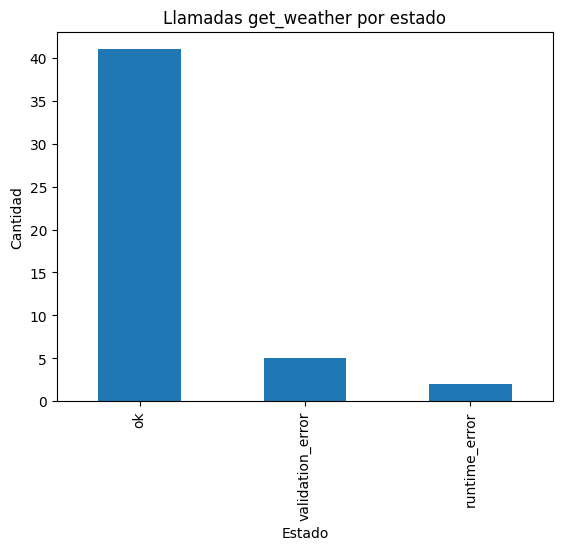

In [ ]:
import pandas as pd

if not LOG_PATH.exists():
    raise FileNotFoundError(f"No existe log en {LOG_PATH.resolve()}. Ejecuta antes las pruebas.")

records = []
with LOG_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

log_df = pd.DataFrame(records)
log_df["timestamp"] = pd.to_datetime(log_df["timestamp"], errors="coerce")
log_df = log_df.sort_values("timestamp").reset_index(drop=True)
# Mostramos las últimas 20 entradas del log para revisión rápida.
recent_log = log_df.tail(20).copy()
display(recent_log[["timestamp", "tool", "fecha_input", "status", "error"]])
# Analizamos el desglose de estados para entender la proporción de llamadas exitosas vs errores. Con dropna=False para incluir posibles valores nulos en el conteo. Renombramos columnas para claridad.
# rename_axis("status") para convertir el índice del conteo en una columna normal llamada "status", y reset_index(name="count") para convertir el resultado en un DataFrame con columnas "status" y "count".
status_counts = log_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count")
total_calls = len(log_df)
ok_calls = int((log_df["status"] == "ok").sum())
success_rate = round((ok_calls / total_calls) * 100, 2) if total_calls else 0.0

print(f"Total llamadas registradas: {total_calls}")
print(f"Llamadas OK: {ok_calls}")
print(f"Tasa de éxito: {success_rate}%")
display(status_counts)


import matplotlib.pyplot as plt

ax = status_counts.plot(kind="bar", x="status", y="count", legend=False, title="Llamadas get_weather por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad")
plt.show()


In [113]:
# Ejemplos de conversación para mostrar resultados finales de forma tabular
demo_questions = [
    "¿Qué puedo ver en Puerto de la Cruz?",
    "¿Qué tiempo hará en Tenerife mañana?",
    "Recuérdame qué me dijiste sobre Puerto de la Cruz y añade el clima de hoy.",
]

chat_history = []
rows = []

for idx, question in enumerate(demo_questions, start=1):
    out = chat_turn(question, k=3, verbose=False)
    rows.append(
        {
            "turno": idx,
            "pregunta": question,
            "respuesta": out["answer"],
            "uso_herramienta": bool(out["tool_outputs"]),
            "num_fuentes": len(out["sources"]),
            "historial_mensajes": out["history_len"],
        }
    )

demo_df = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 220)
display(demo_df)

,turno,pregunta,respuesta,uso_herramienta,num_fuentes,historial_mensajes
0,1,¿Qué puedo ver en Puerto de la Cruz?,"En Puerto de la Cruz puedes visitar el Loro Parque, considerado el Mejor Zoológico del Mundo. También puedes pasear desde el Muelle hasta la Playa Martiánez recorriendo la Calle de [Fuente 1, Fuente 2].",False,3,2
1,2,¿Qué tiempo hará en Tenerife mañana?,"Mañana en Tenerife se esperan cielos parcialmente nublados, con una temperatura máxima de 21.4 °C y una mínima de 12.2 °C.",True,0,4
2,3,Recuérdame qué me dijiste sobre Puerto de la Cruz y añade el clima de hoy.,"Para 2026-06-07 en Tenerife, España: mín 11.8°C, máx 20.7°C, condición principalmente despejado.",True,3,6


In [127]:
# Verificación de coste: clima puro debería evitar RAG, consulta mixta debería usar RAG
chat_history = []

q_weather_only = "¿Qué tiempo hará en Tenerife mañana?"
q_mixed = "Recomiéndame una playa tranquila y dime el tiempo de mañana"

out_weather_only = chat_turn(q_weather_only, k=3, verbose=False)
out_mixed = chat_turn(q_mixed, k=3, verbose=False)

print("Pregunta 1:", q_weather_only)
print("RAG utilizado:", out_weather_only["rag_used"])
print("Tool usada:", bool(out_weather_only["tool_outputs"]))
print("Fuentes:", len(out_weather_only["sources"]))

print("\nPregunta 2:", q_mixed)
print("RAG utilizado:", out_mixed["rag_used"])
print("Tool usada:", bool(out_mixed["tool_outputs"]))
print("Fuentes:", len(out_mixed["sources"]))

Pregunta 1: ¿Qué tiempo hará en Tenerife mañana?
RAG utilizado: False
Tool usada: True
Fuentes: 0

Pregunta 2: Recomiéndame una playa tranquila y dime el tiempo de mañana
RAG utilizado: True
Tool usada: True
Fuentes: 3


### KPI de coste estimado (con y sin optimización)

Estimamos coste relativo por turno con unidades simples:

- `1.0` unidad si se ejecuta retrieval RAG.
- `0.2` unidades si se usa la herramienta de clima.

Comparamos:

- **Costo actual**: usa el enrutado optimizado (puede saltar RAG en clima puro).
- **Costo baseline**: asume que siempre se ejecuta RAG.

,turno,pregunta,rag_usado,tool_usada,coste_actual,coste_baseline,ahorro
0,1,¿Qué tiempo hará en Tenerife hoy?,False,True,0.2,1.2,1.0
1,2,¿Y mañana?,False,True,0.2,1.2,1.0
2,3,¿Qué playas tranquilas recomiendas en Tenerife?,True,False,1.0,1.0,0.0
3,4,Recomiéndame una playa tranquila y dime el tiempo de mañana,True,True,1.2,1.2,0.0
4,5,¿Qué ver en Puerto de la Cruz?,True,False,1.0,1.0,0.0
5,6,¿Qué temperatura habrá el 2026-06-12 en Tenerife?,False,True,0.2,1.2,1.0



Resumen coste estimado
--------------------------------------------------
Coste actual total:   3.80
Coste baseline total: 6.80
Ahorro estimado:      3.00 (44.12%)


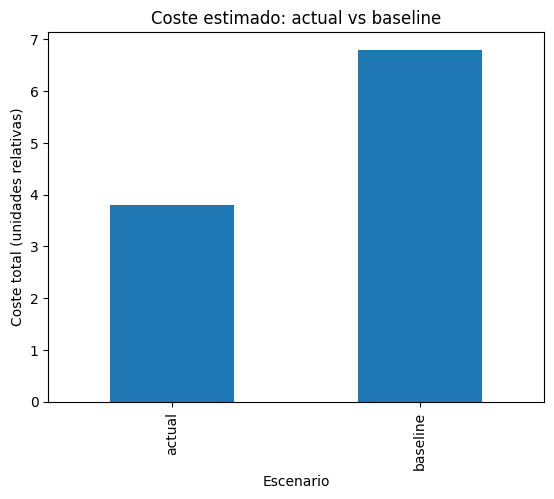

In [114]:
# Evaluación de coste estimado en un conjunto mixto de preguntas
cost_eval_questions = [
    "¿Qué tiempo hará en Tenerife hoy?",
    "¿Y mañana?",
    "¿Qué playas tranquilas recomiendas en Tenerife?",
    "Recomiéndame una playa tranquila y dime el tiempo de mañana",
    "¿Qué ver en Puerto de la Cruz?",
    "¿Qué temperatura habrá el 2026-06-12 en Tenerife?",
]

RAG_COST_UNIT = 1.0
TOOL_COST_UNIT = 0.2

chat_history = []
cost_rows = []

for i, q in enumerate(cost_eval_questions, start=1):
    out = chat_turn(q, k=3, verbose=False)
    rag_used = bool(out.get("rag_used", False))
    tool_used = bool(out.get("tool_outputs"))

    current_cost = (RAG_COST_UNIT if rag_used else 0.0) + (TOOL_COST_UNIT if tool_used else 0.0)
    baseline_cost = RAG_COST_UNIT + (TOOL_COST_UNIT if tool_used else 0.0)
    savings = baseline_cost - current_cost

    cost_rows.append(
        {
            "turno": i,
            "pregunta": q,
            "rag_usado": rag_used,
            "tool_usada": tool_used,
            "coste_actual": round(current_cost, 2),
            "coste_baseline": round(baseline_cost, 2),
            "ahorro": round(savings, 2),
        }
    )

cost_df = pd.DataFrame(cost_rows)
display(cost_df)

tot_current = float(cost_df["coste_actual"].sum())
tot_baseline = float(cost_df["coste_baseline"].sum())
tot_savings = round(tot_baseline - tot_current, 2)
saving_pct = round((tot_savings / tot_baseline) * 100, 2) if tot_baseline else 0.0

print("\nResumen coste estimado")
print("-" * 50)
print(f"Coste actual total:   {tot_current:.2f}")
print(f"Coste baseline total: {tot_baseline:.2f}")
print(f"Ahorro estimado:      {tot_savings:.2f} ({saving_pct}%)")

summary_cost_df = pd.DataFrame(
    [
        {"escenario": "actual", "coste_total": tot_current},
        {"escenario": "baseline", "coste_total": tot_baseline},
    ]
)

ax = summary_cost_df.plot(
    kind="bar",
    x="escenario",
    y="coste_total",
    legend=False,
    title="Coste estimado: actual vs baseline",
)
ax.set_xlabel("Escenario")
ax.set_ylabel("Coste total (unidades relativas)")
plt.show()

## Observabilidad de uso del LLM

En esta sección se registran métricas por turno y se visualizan:

- Tokens de entrada/salida/total.
- Latencia del LLM, retrieval y turno completo.
- Coste estimado (unidades relativas y coste LLM aproximado).

In [124]:
# Ejecuta algunos turnos para poblar el log de observabilidad
chat_history = []
obs_questions = [
    "¿Qué tiempo hará en Tenerife hoy?",
    "¿Y mañana?",
    "¿Qué ver en Puerto de la Cruz?",
    "Recomiéndame una playa tranquila y dime el tiempo de mañana",
]

for q in obs_questions:
    _ = chat_turn(q, k=3, verbose=False)

print("Log de observabilidad generado en:", TURN_METRICS_LOG_PATH.resolve())

Log de observabilidad generado en: C:\Users\Usuario\OneDrive\Pontia\Modulo 6 - LLMs\Entrega Final\logs\turn_metrics.log


,timestamp,question,rag_used,tool_used,tool_calls,source_count,llm_calls,input_tokens,output_tokens,total_tokens,llm_latency_ms,retrieval_latency_ms,turn_latency_ms,estimated_cost_units,estimated_llm_cost
0,2026-06-08 11:21:48,¿Qué tiempo hará en Tenerife hoy?,False,True,1,0,2,440,14,454,1744.26,0.00,5279.88,0.2,0.00454
1,2026-06-08 11:21:51,¿Y mañana?,False,True,1,0,2,542,23,565,1342.20,0.00,2654.64,0.2,0.00565
2,2026-06-08 11:21:52,¿Qué ver en Puerto de la Cruz?,True,False,0,3,1,676,66,742,729.58,738.46,1470.06,1.0,0.00742
3,2026-06-08 11:21:56,Recomiéndame una playa tranquila y dime el tiempo de mañana,True,True,1,3,2,1403,258,1661,2155.32,425.58,3809.51,1.2,0.01661
4,2026-06-08 11:23:17,¿Qué tiempo hará en Tenerife hoy?,False,True,1,0,2,440,50,490,1620.65,0.00,3006.64,0.2,0.00490
5,2026-06-08 11:23:20,¿Y mañana?,False,True,1,0,2,526,56,582,1444.19,0.00,2569.17,0.2,0.00582
6,2026-06-08 11:23:21,¿Qué ver en Puerto de la Cruz?,True,False,0,3,1,673,47,720,651.53,665.29,1318.65,1.0,0.00720
7,2026-06-08 11:23:24,Recomiéndame una playa tranquila y dime el tiempo de mañana,True,True,1,3,2,1359,79,1438,1321.45,404.19,2751.76,1.2,0.01438


Resumen de observabilidad
--------------------------------------------------


,metric,value
0,turnos,8.00000
1,tokens_entrada_total,6059.00000
2,tokens_salida_total,593.00000
3,tokens_totales,6652.00000
4,latencia_llm_promedio_ms,1376.15000
5,latencia_turno_promedio_ms,2857.54000
6,latencia_turno_p95_ms,4765.25000
7,coste_estimado_unidades_total,5.20000
8,coste_llm_estimado_total,0.06652


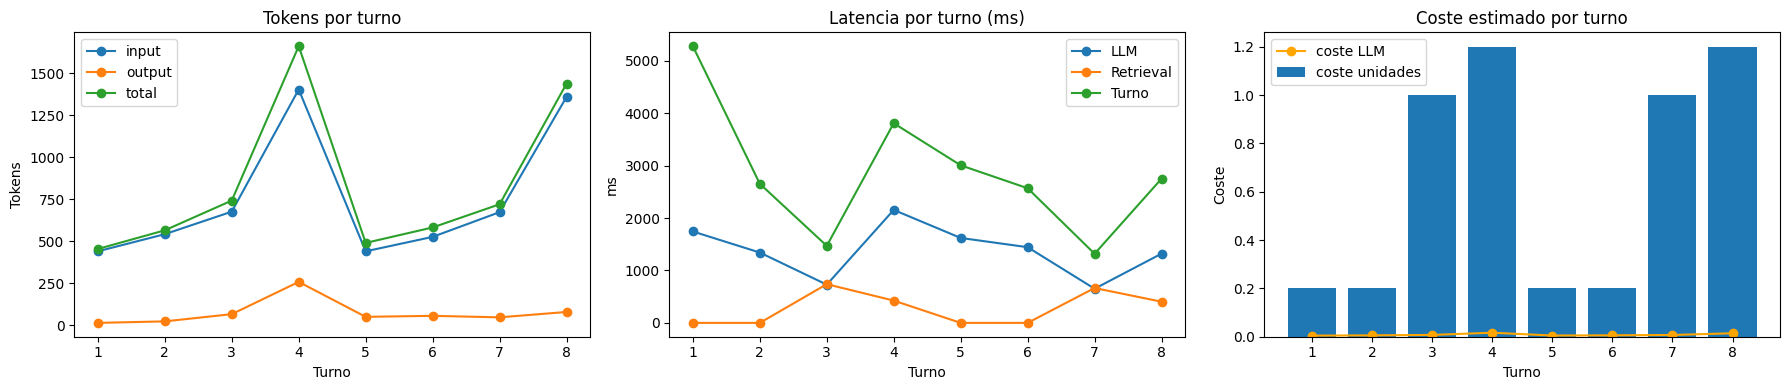

In [126]:
import matplotlib.pyplot as plt
import pandas as pd

if not TURN_METRICS_LOG_PATH.exists():
    raise FileNotFoundError(f"No existe {TURN_METRICS_LOG_PATH.resolve()}. Ejecuta la celda anterior.")

turn_records = []
with TURN_METRICS_LOG_PATH.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            turn_records.append(json.loads(line))

obs_df = pd.DataFrame(turn_records)
obs_df["timestamp"] = pd.to_datetime(obs_df["timestamp"], errors="coerce")
obs_df = obs_df.sort_values("timestamp").reset_index(drop=True)

display(obs_df.tail(20))

summary_obs = pd.DataFrame(
    [
        {"metric": "turnos", "value": int(len(obs_df))},
        {"metric": "tokens_entrada_total", "value": int(obs_df["input_tokens"].sum())},
        {"metric": "tokens_salida_total", "value": int(obs_df["output_tokens"].sum())},
        {"metric": "tokens_totales", "value": int(obs_df["total_tokens"].sum())},
        {"metric": "latencia_llm_promedio_ms", "value": round(float(obs_df["llm_latency_ms"].mean()), 2)},
        {"metric": "latencia_turno_promedio_ms", "value": round(float(obs_df["turn_latency_ms"].mean()), 2)},
        {"metric": "latencia_turno_p95_ms", "value": round(float(obs_df["turn_latency_ms"].quantile(0.95)), 2)},
        {"metric": "coste_estimado_unidades_total", "value": round(float(obs_df["estimated_cost_units"].sum()), 3)},
        {"metric": "coste_llm_estimado_total", "value": round(float(obs_df["estimated_llm_cost"].sum()), 6)},
    ]
)

print("Resumen de observabilidad")
print("-" * 50)
display(summary_obs)

plot_df = obs_df.tail(25).copy()
plot_df["turno"] = range(1, len(plot_df) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(plot_df["turno"], plot_df["input_tokens"], marker="o", label="input")
axes[0].plot(plot_df["turno"], plot_df["output_tokens"], marker="o", label="output")
axes[0].plot(plot_df["turno"], plot_df["total_tokens"], marker="o", label="total")
axes[0].set_title("Tokens por turno")
axes[0].set_xlabel("Turno")
axes[0].set_ylabel("Tokens")
axes[0].legend()

axes[1].plot(plot_df["turno"], plot_df["llm_latency_ms"], marker="o", label="LLM")
axes[1].plot(plot_df["turno"], plot_df["retrieval_latency_ms"], marker="o", label="Retrieval")
axes[1].plot(plot_df["turno"], plot_df["turn_latency_ms"], marker="o", label="Turno")
axes[1].set_title("Latencia por turno (ms)")
axes[1].set_xlabel("Turno")
axes[1].set_ylabel("ms")
axes[1].legend()

axes[2].bar(plot_df["turno"], plot_df["estimated_cost_units"], label="coste unidades")
axes[2].plot(plot_df["turno"], plot_df["estimated_llm_cost"], marker="o", color="orange", label="coste LLM")
axes[2].set_title("Coste estimado por turno")
axes[2].set_xlabel("Turno")
axes[2].set_ylabel("Coste")
axes[2].legend()

plt.tight_layout()
plt.show()